# Exploration des données Open Food Facts pour Santé publique France

### Table des matières

* [**1. Introduction**](#chapter1)
* [**2. Aperçu du jeu de données**](#chapter2)
    * [2.1. Chargement](#section_2_1)
    * [2.2. Dimensions](#section_2_2)
    * [2.3. Entête](#section_2_3)
    * [2.4. Types](#section_2_4)
    * [2.5. Valeurs manquantes](#section_2_5)
* [**3. Choix et cadrage de l'étude**](#chapter3)
    * [3.1. Choix pour l'étude](#section_3_1)
    * [3.2. Valeurs manquantes](#section_3_2)
    * [3.3. Filtrage des pays](#section_3_3)
    * [3.4. Sélection des variables](#section_3_4)
* [**4. Nettoyage des données**](#chapter4)
    * [4.1. Valeurs manquantes](#section_4_1)
    * [4.2. Doublons](#section_4_2)
    * [4.3. Valeurs aberrantes](#section_4_3)
    * [4.4. Valeurs atypiques](#section_4_4)
    * [4.5. Imputation des valeurs manquantes](#section_4_5)
    * [4.6. Export des données nettoyées](#section_4_6)
* [**5. Analyse exploratoire**](#chapter5)
    * [5.1. Visualisation des distributions](#section_5_1)
    * [5.2. Analyse multivariée](#section_5_2)
    * [5.3. Hypothèses](#section_5_3)
    * [5.4. Anova](#section_5_4)
    * [5.5. ACP](#section_5_5)
* [**6. Conclusion**](#chapter6)


## 1 - Introduction <a class="anchor" id="chapter1"></a>

Santé publique France est un établissement public ayant pour mission d'améliorer et protéger la santé des populations.  
Open Food Facts est un projet collaboratif permettant la constitution d'une base de données ouverte sur les produits alimentaires à travers le monde entier.  

Santé publique France souhaite rendre cette base de données plus accessibles afin que ses agents puissent les utiliser.

Ce document contient une exploration de ces données afin que les agents de Santé publique France puissent s'appuyer sur ses résultats.


## 2 - Aperçu du jeu de données <a class="anchor" id="chapter2"></a>

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use('seaborn')

### 2.1 - Chargement <a class="anchor" id="section_2_1"></a>

In [2]:
data_path = "./data/"
datas = pd.read_csv(data_path + "fr.openfoodfacts.org.products.csv", sep='\t',low_memory=False)


### 2.2 - Dimensions <a class="anchor" id="section_2_2"></a>

In [3]:
print(f'Le jeu de données comporte {datas.shape[0]} lignes et {datas.shape[1]} colonnes' )

Le jeu de données comporte 320772 lignes et 162 colonnes


### 2.3 - Entête <a class="anchor" id="section_2_3"></a>

In [4]:
datas.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,...,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
0,0000000003087,http://world-fr.openfoodfacts.org/produit/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000000004530,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,14.0,14.0,NaN,NaN
2,0000000004559,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Peanuts,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,0000000016087,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489055731,2017-03-09T10:35:31Z,1489055731,2017-03-09T10:35:31Z,Organic Salted Nut Mix,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,12.0,NaN,NaN
4,0000000016094,http://world-fr.openfoodfacts.org/produit/0000...,usda-ndb-import,1489055653,2017-03-09T10:34:13Z,1489055653,2017-03-09T10:34:13Z,Organic Polenta,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Le jeu de données est composé de produits et d'informations associées à ces produits.  
L'aperçu de l'entête n'apporte pas plus d'informations.  
Il y a trop de colonnes pour les visualiser dans ce tableau.

### 2.4 - Types de données <a class="anchor" id="section_2_4"></a>

In [5]:
datas.dtypes.value_counts()

float64    106
object      56
dtype: int64

Il y a 106 colonnes quantitatives et 56 colonnes qualitatives.

### 2.5 - Valeurs manquantes <a class="anchor" id="section_2_5"></a>

<AxesSubplot:>

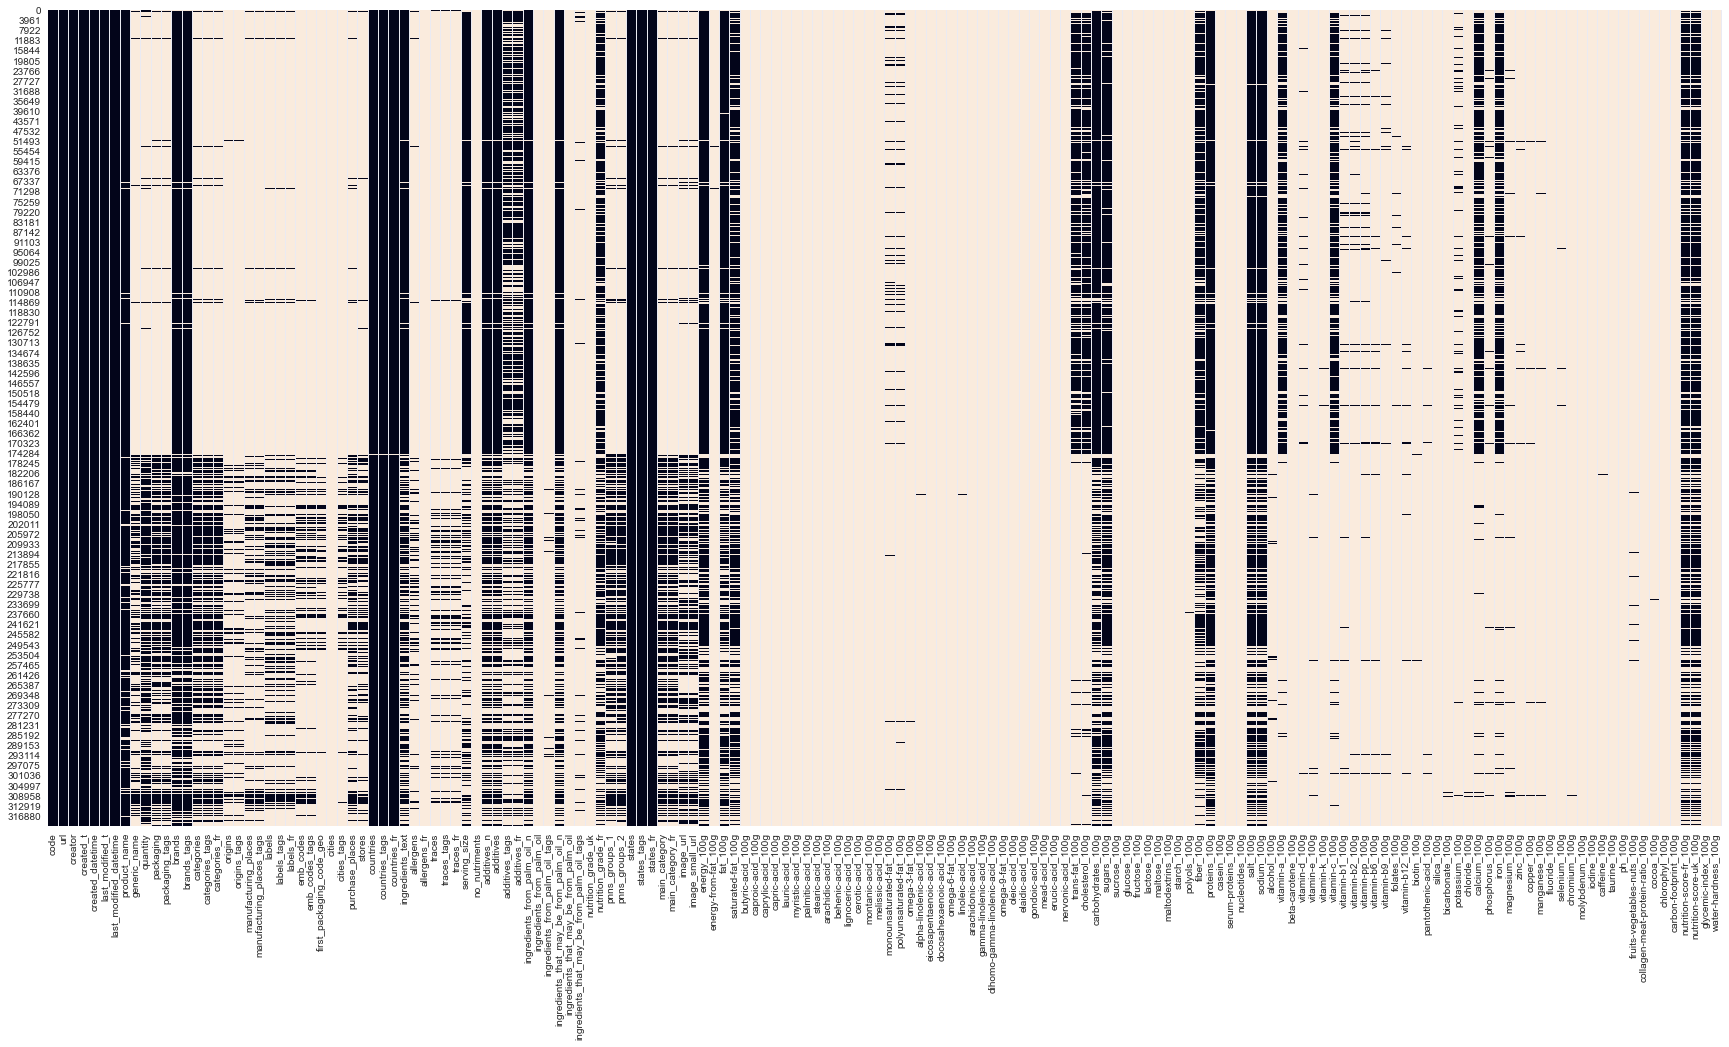

In [6]:

plt.figure(figsize=(30,15))
sns.heatmap(datas.isna(),cbar=False)

Il y a beaucoup de valeurs manquantes.  
Ces valeurs manquantes seront à traiter.

## 3 - Choix et cadrage de l'étude <a class="anchor" id="chapter3"></a>

### 3.1 - Choix pour l'étude <a class="anchor" id="section_3_1"></a>

Le jeu de données se compose de produits et de leurs informations associées.

Ces informations peuvent se catégoriser par:
- Des informations générales comme le contributeur qui a ajouté le produit, la date de création, le code barre ou encore le nom du produit.  
- Des étiquettes comme le packaging, l'origine, la catégorie, etc...
- Les ingrédients
- Des informations diverses comme les additifs, la présence d'huile de palme, le nutrition grade ('a' à 'e')...
- Les nutriments (les apports nutritionnels) et le nutriscore

Cette étude est à destination des agents de Santé publique France.  
Le nutriscore, présent dans cette base de données, permet d'évaluer de la qualité d'un produit d'un point de vue santé.  
Le nutriscore est établi à partir de la composition des aliments, notamment des nutriments qui le composent.  

Cette étude va se focaliser sur l'impact que peuvent avoir les différents nutriments sur le nutriscore à partir du jeu de données.






### 3.2 - Valeurs manquantes <a class="anchor" id="section_3_2"></a>

Quelques fonctions permettant de calculer, présenter ou afficher les valeurs manquantes:

In [7]:
# retourne le pourcentage de valeurs manquantes pour chaque colonne de la dataframe passée en paramètre
def valeurs_manquantes(df):
    valeurs_manquantes = ((df.isna().sum()/df.shape[0])*100).sort_values(ascending=False)  
    return valeurs_manquantes

In [8]:
# affichage du pourcentage des valeurs manquantes par colonne pour une dataframe donnée ainsi que le seuil choisi
def graph_valeurs_manquantes(df, seuil_valeurs_manquantes=90):
    df_valeurs_manquantes = table_valeurs_manquantes(df)
    plt.figure(figsize=(30,15))
    sns.barplot(data=df_valeurs_manquantes,x=df_valeurs_manquantes.index,y=df_valeurs_manquantes.columns[0])
    plt.xticks(rotation = 90)
    plt.axhline(y = seuil_valeurs_manquantes, color ='red')
    return plt.show()


In [9]:
# retourne le pourcentage des valeurs manquantes des colonnes d'une dataframe dans une dataframe
def table_valeurs_manquantes(df):
    return pd.DataFrame(valeurs_manquantes(df),columns=['% de valeurs manquantes'])


Pour identifier les variables qui ne sont pas pertinentes à garder,  
le graphique ci-dessous affiche le pourcentage de valeurs manquantes par variable.

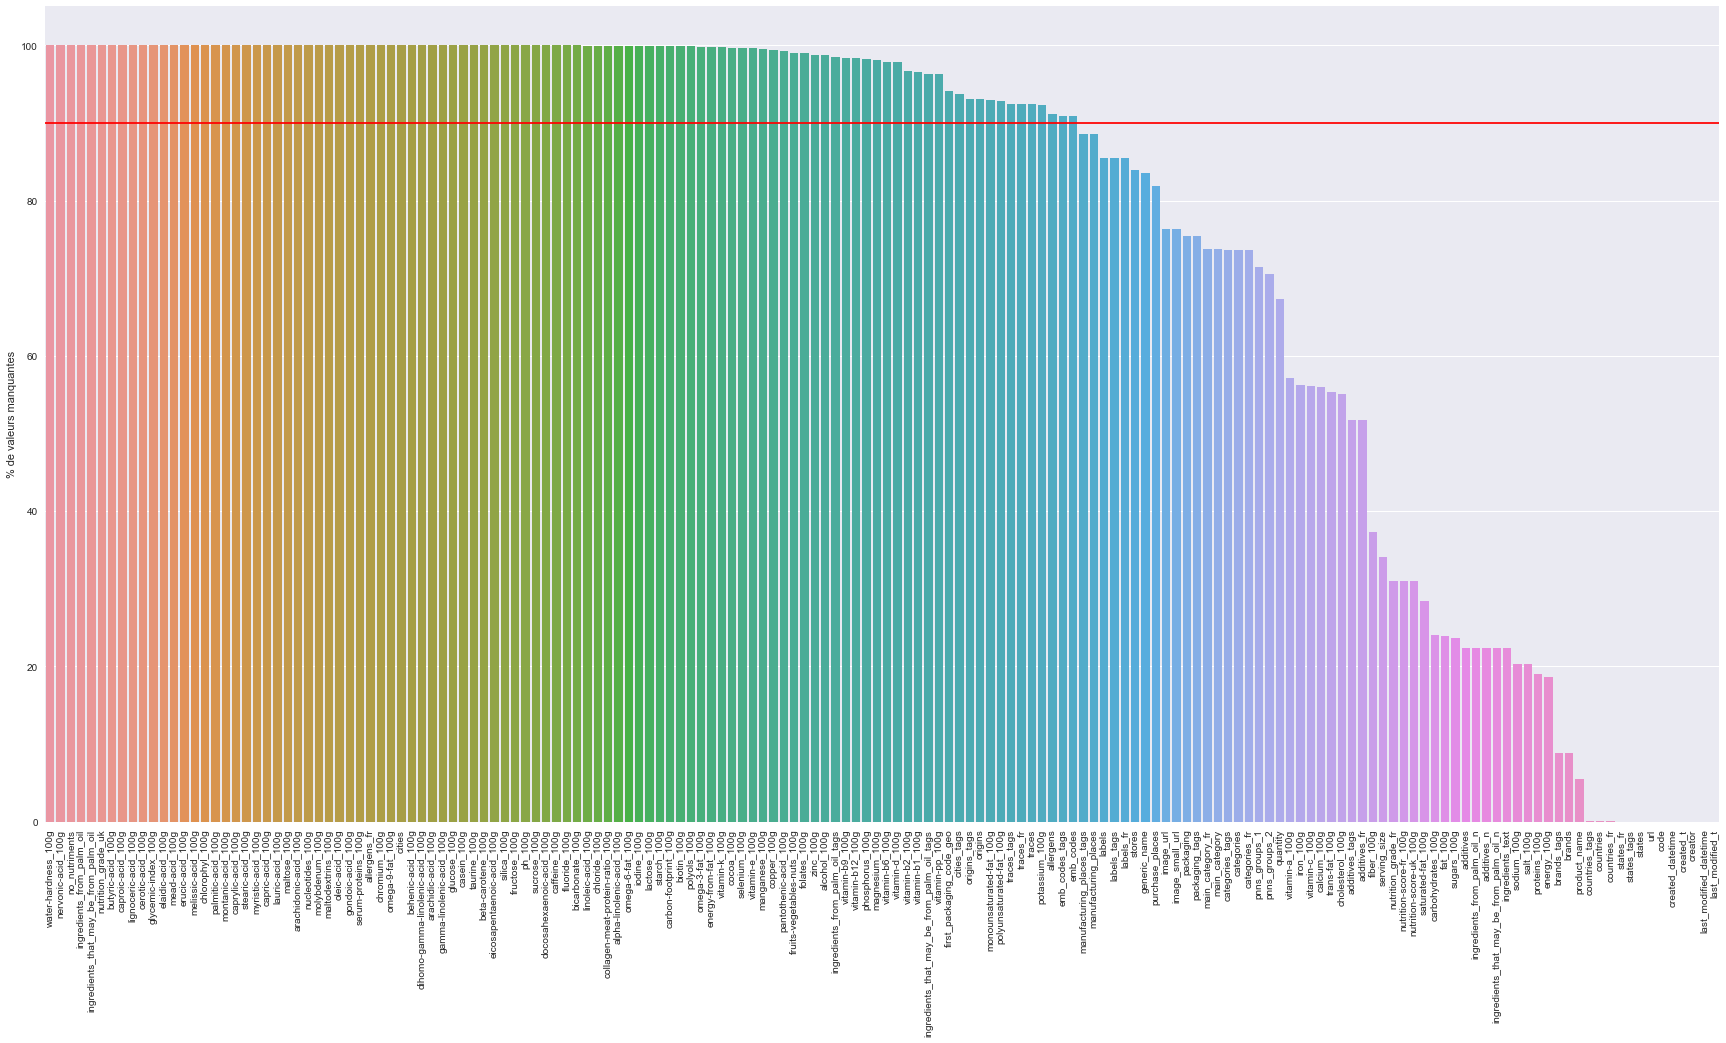

In [10]:
graph_valeurs_manquantes(datas)

Au delà de 90% de valeurs manquantes, la variable contient trop peu de données pour être exploitable dans une analyse.  
Cela supprime un grand nombre de colonnes.  
Les seuils de 70 ou 80 pourcents peuvent éventuellement être choisis, cependant cela réduirait de manière conséquente le nombre de variables.  
Le seuil de 90% est gardé pour supprimer les colonnes.  

Suppression des colonnes:

In [11]:
seuil_valeurs_manquantes = 90

In [12]:
# supprime les colonnes de la dataframe datas dont le seuil des valeurs manquantes est supérieur au seuil passé en parmètre 
def colonnes_valeurs_manquantes(seuil_valeurs_manquantes):
    valeurs_manquantes = ((datas.isna().sum()/datas.shape[0])*100) 
    return datas.columns[valeurs_manquantes<=seuil_valeurs_manquantes]

In [13]:
colonnes_number_before = datas.shape[1]
colonnes_number_after = datas[colonnes_valeurs_manquantes(seuil_valeurs_manquantes)].shape[1]
print(f"{colonnes_number_before - colonnes_number_after} colonnes ont plus de {seuil_valeurs_manquantes}% de valeurs manquantes")

100 colonnes ont plus de 90% de valeurs manquantes


In [14]:
datas = datas[colonnes_valeurs_manquantes(seuil_valeurs_manquantes)]

Aperçu après la suppression:

In [15]:
table_valeurs_manquantes(datas)

,% de valeurs manquantes
manufacturing_places_tags,88.622760
manufacturing_places,88.620890
labels,85.485329
labels_tags,85.458831
labels_fr,85.451972
...,...
created_datetime,0.002806
created_t,0.000935
creator,0.000623
last_modified_datetime,0.000000


Il n'y a plus de colonnes avec plus de 90% de valeurs manquantes

### 3.3 - Filtrage des pays <a class="anchor" id="section_3_3"></a>


Les données étant utilisées par Santé publique France, l'analyse sera faite sur les produits vendus en France.  
La colonne 'countries_fr' apporte cette information.  

Aperçu des différents pays:

In [16]:
datas['countries_fr'].value_counts()


États-Unis                                                                                                                                                                                                          172998
France                                                                                                                                                                                                               94392
Suisse                                                                                                                                                                                                               14953
Allemagne                                                                                                                                                                                                             7870
Espagne                                                                                                                     

La France fait parfois partie d'une liste de pays. Ces lignes seront donc gardées, le produit étant vendu en France.

In [17]:
print(f"{datas[datas['countries_fr'].str.contains('France', na=False)].shape[0]} produits sont des produits vendus en France")

98440 produits sont des produits vendus en France


Suppression des produits non vendus en France:

In [18]:
datas = datas[datas['countries_fr'].str.contains("France", na=False)]

Le fait d'enlever des lignes peut changer le pourcentage de valeurs manquantes pour une colonne.  
Vérification:

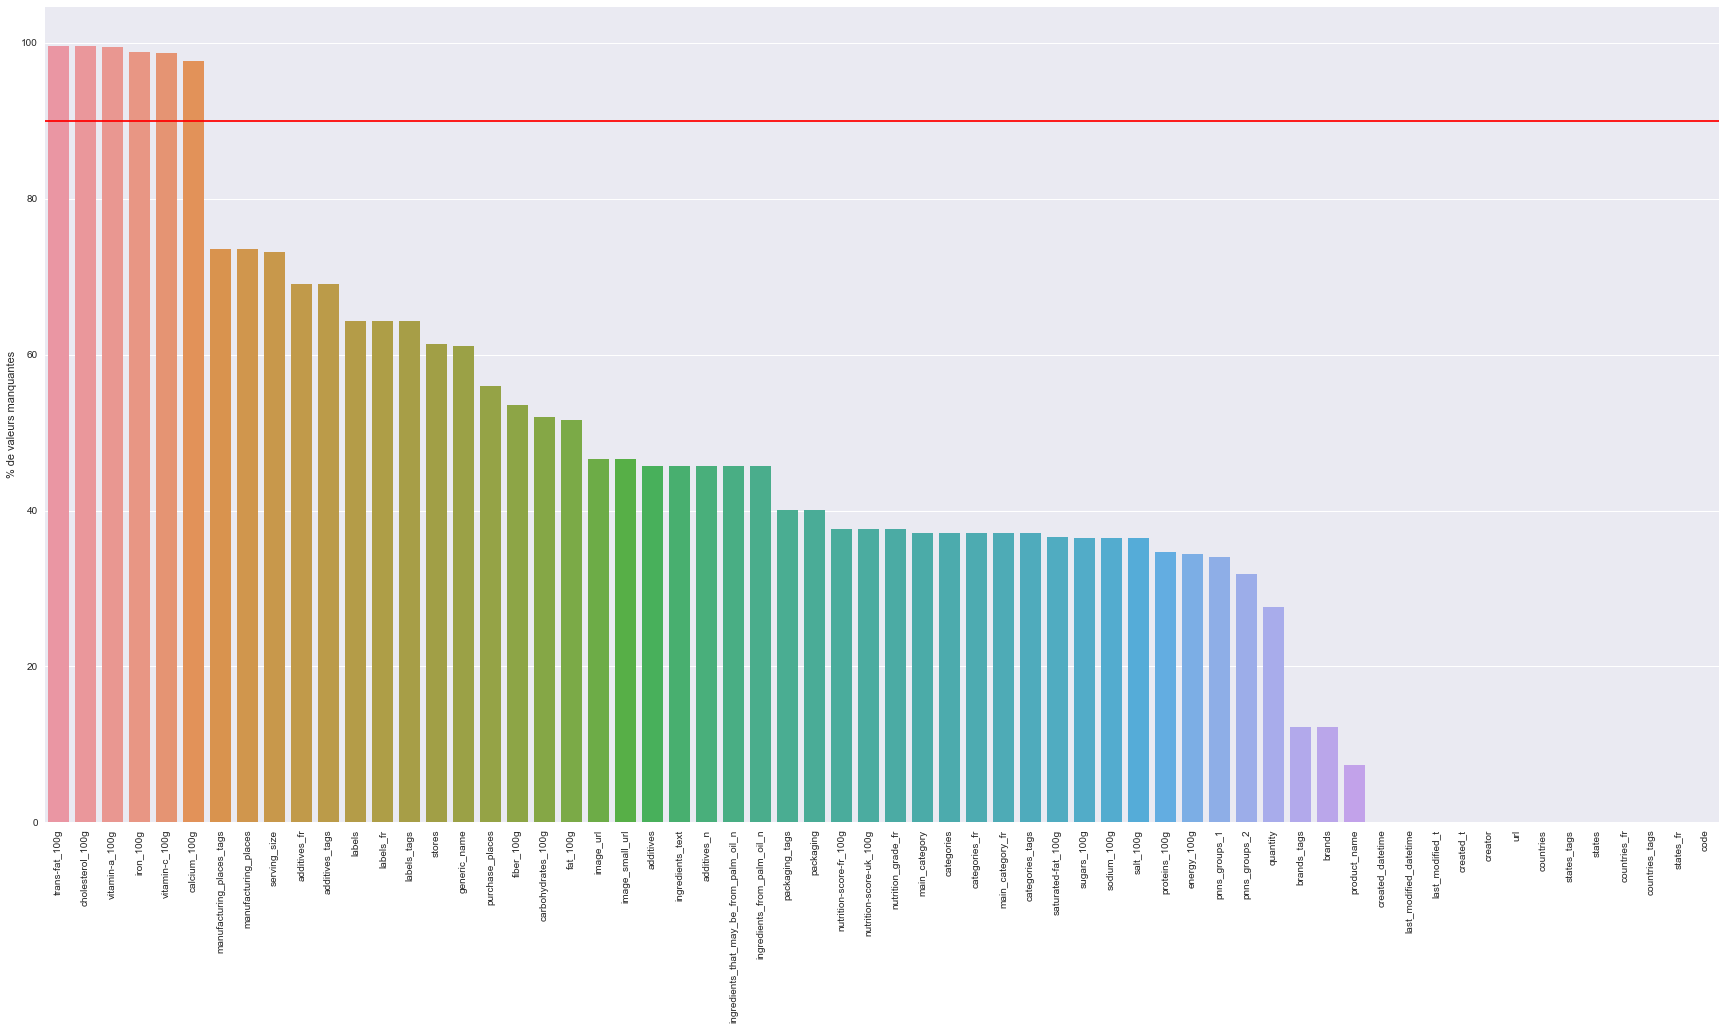

In [19]:
graph_valeurs_manquantes(datas, seuil_valeurs_manquantes)

6 colonnes ont plus de 90% de valeurs manquantes.  
L'explication est que ces nutriments sont très peu ou pas du tout indiqués sur des produits vendus en France.  
Suppression de ces colonnes:

In [20]:
datas = datas[colonnes_valeurs_manquantes(seuil_valeurs_manquantes)]

### 3.4 - Sélection des variables <a class="anchor" id="section_3_4"></a>

Dans le cadre de cette étude, toutes les colonnes terminant par "_100g" sont gardées.  
Ce sont les colonnes correspondant aux informations nutritionnelles pour 100 grammes.

Parmi les colonnes qualitatives, seules sont gardées:
- la colonne product_name (qui contient le nom du produit) et
- la colonne nutrition_grade_fr (qui contient le score de 'a' à 'e')  

Ainsi sont gardés dans le jeu d'étude le nom du produit et les informations nutritionnelles associées.

In [21]:
kept_qualitative_columns=['nutrition_grade_fr','product_name']

In [22]:
nutrition_columns = datas.filter(regex=(".*_100g")).columns 

In [23]:
nutrition_columns

Index(['energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g',
       'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g', 'nutrition-score-fr_100g', 'nutrition-score-uk_100g'],
      dtype='object')

Parmi les informations nutrtionnelles, deux colonnes sont relatives au nutriscore :  
'nutrition-score-fr_100g' et  'nutrition-score-uk_100g'  
Le nutriscore français sera évidemment gardé dans le cadre de cette étude (et pas le nutriscore UK).  
On peut supposer que ces deux variables sont corrélées, et que nutrition-score-uk_100g n'apporterait pas plus d'informations.   
A titre indicatif, visualisation de ces deux variables l'une par rapport à l'autre:



<AxesSubplot:xlabel='nutrition-score-fr_100g', ylabel='nutrition-score-uk_100g'>

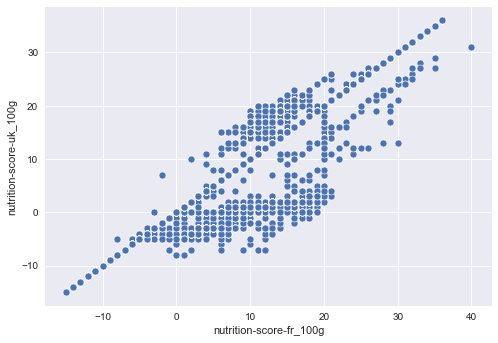

In [24]:
sns.scatterplot(data=datas, x="nutrition-score-fr_100g", y="nutrition-score-uk_100g")


In [25]:
nutrition_columns = nutrition_columns.drop('nutrition-score-uk_100g')

Suppression des colonnes non gardées:

In [26]:
datas = datas.loc[:,kept_qualitative_columns + nutrition_columns.tolist()]
datas

,nutrition_grade_fr,product_name,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g
0,NaN,Farine de blé noir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,Filet de bœuf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,e,Lion Peanut x2,1883.0,20.0,12.5,70.0,57.5,2.5,2.5,0.09652,0.038,22.0
136,NaN,Twix x2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
320761,NaN,Roussette du Bugey (2011),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320763,c,Thé vert Earl grey,21.0,0.2,0.2,0.5,0.5,0.2,0.5,0.02540,0.010,2.0
320764,NaN,"Cheese cake thé vert, yuzu",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320765,NaN,Rillette d'oie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4 - Nettoyage des données <a class="anchor" id="chapter4"></a>

### 4.1 - Valeurs manquantes <a class="anchor" id="section_4_1"></a>

Aperçu des valeurs manquantes du jeu de données après les premières étapes:

In [27]:
table_valeurs_manquantes(datas)

,% de valeurs manquantes
fiber_100g,53.552418
carbohydrates_100g,52.040837
fat_100g,51.603007
nutrition-score-fr_100g,37.611743
nutrition_grade_fr,37.611743
saturated-fat_100g,36.636530
sugars_100g,36.494311
sodium_100g,36.437424
salt_100g,36.434376
proteins_100g,34.662739


La colonne produit identifie le produit. Les 7.3% d'individus sans nom de produits seront supprimés.  
Les colonnes 'nutrition-score-fr_100g' et 'nutrition_grade_fr' sont les valeurs cibles de l'étude.    
Il n'y a pas d'intérêt à garder les individus sans ces informations, ils seront supprimés.  

Pour les informations nutritionnelles, afin de faire des analyses statistiques, il va falloir imputer ces valeurs manquantes avec des valeurs. Cette imputation sera effectuée ultérieurement.  


In [28]:
initial_rows = datas.shape[0]

Suppression des individus sans nom de produit:

In [29]:
print(f"{datas[datas['product_name'].isna()].shape[0]} individus n'ont pas de nom de produit")

7193 individus n'ont pas de nom de produit


In [30]:
datas = datas.dropna(subset=['product_name'])

Suppression des individus sans nutrition score / grade

In [31]:
print(f"Parmi ceux qui restent, {datas[datas['nutrition-score-fr_100g'].isna()].shape[0]} individus n'ont pas de nutrition score")

Parmi ceux qui restent, 30175 individus n'ont pas de nutrition score


In [32]:
datas = datas.dropna(subset=['nutrition-score-fr_100g'])

In [33]:
print(f"Parmi ceux qui restent, {datas[datas['nutrition_grade_fr'].isna()].shape[0]} individus n'ont pas de nutrition grade")

Parmi ceux qui restent, 0 individus n'ont pas de nutrition grade


In [34]:
print(f"{initial_rows - datas.shape[0]} lignes ont été supprimées lors de la suppression des lignes sans nom de produit ou sans nutrition score / grade.")

37368 lignes ont été supprimées lors de la suppression des lignes sans nom de produit ou sans nutrition score / grade.


### 4.2 - Doublons <a class="anchor" id="section_4_1"></a>

Les doublons peuvent fausser les analyses de données. Dans cette partie, les doublons vont être identifiés et traités.

Premier aperçu des doublons:

In [35]:
doublons = datas.duplicated().value_counts()
print("Doublons:")
print(doublons)
print(f"\n{datas[datas.duplicated() == True].shape[0]} individus sont des doublons")


Doublons:
False    60180
True       892
dtype: int64

892 individus sont des doublons


Ces lignes sont en double et peuvent être supprimées. La ligne la plus récente est gardée

In [36]:
initial_rows = datas.shape[0]

In [37]:
datas = datas.drop_duplicates(keep='last')

Les individus représentent des produits et leurs informations associées.  
Il se peut que le même nom de produit soit présent dans le jeu de données sur plusieurs individus. 

In [38]:
duplicated_products = datas.duplicated(['product_name'],keep=False)

print(f"Noms de produits présents plusieurs fois dans le jeu de données:\n")
print(datas[duplicated_products].value_counts(['product_name']))


Noms de produits présents plusieurs fois dans le jeu de données:

product_name                    
Mayonnaise                          39
Orange                              36
Huile d'olive vierge extra          31
Mozzarella                          30
Jus d'orange                        30
                                    ..
Naturea                              2
Nappage caramel                      2
Napolitaine à l'huile d'olive        2
Napolitaine aux légumes cuisinés     2
1 Onglet                             2
Length: 3960, dtype: int64


Il existe de nombreuses lignes avec le même nom de produits.    

Plus précisément:

In [39]:
# calcul du nombre de produits et de noms de produits dupliqués ainsi que le nombre d'individus à supprimer pour l'unicité
#  paramètres :
# df : la dataframe à analyser
# duplicated_products : retour de la fonction dataframe.duplicated : serie de valeurs booléennes
# product_name_column : la colonne sur laquelle les doublons sont analysés
def duplicated_products_stats(df,duplicated_products,product_name_column):
    
    # taille du dataframe
    datas_len = df.shape[0]
    # nombre de produits dupliqués
    duplicated_products_len = duplicated_products.sum()
    # nombre de noms de produits dupliqués
    duplicated_products_names_len = len(df[duplicated_products].value_counts([product_name_column]))
    # taille du dataframe sans duplicats
    without_duplicate_len =  datas_len - duplicated_products_len + duplicated_products_names_len
    
    return [duplicated_products_len, duplicated_products_names_len, without_duplicate_len]
    

In [40]:
# print des résultats de la fonction duplicated_products_stats
# paramètres:
# df : la dataframe sur laquelle les doublons sont analysés
# results : les résultats de la fonction duplicated_products_stats
def print_duplicated_products_stats_results(df,results):
    print(f"Taille initiale du jeu de données: {df.shape[0]}.\n")
    print(f"{results[0]} individus du jeu de données possèdent au moins un autre individu avec le même nom de produit.")
    print(f"{results[1]} noms de produits possèdent au moins deux individus du jeu de données avec ce nom.\n")
    print(f"En enlevant ces produits, il reste {results[2]} individus dans le jeu de données.")
    

In [41]:
duplicated_products_stats_results = duplicated_products_stats(datas,duplicated_products,'product_name')
print_duplicated_products_stats_results(datas,duplicated_products_stats_results)


Taille initiale du jeu de données: 60180.

13007 individus du jeu de données possèdent au moins un autre individu avec le même nom de produit.
3960 noms de produits possèdent au moins deux individus du jeu de données avec ce nom.

En enlevant ces produits, il reste 51133 individus dans le jeu de données.


Le nom du produit n'est pas toujours écrit de la même manière.  
Il peut contenir des majuscules, plusieurs espaces, des parenthèses...
Un même produit écrit différemment est un doublon.  

Exemple:


In [42]:
datas[datas['product_name'].str.lower().str.contains('vermicelles de riz',na=False)]


,nutrition_grade_fr,product_name,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g
210617,a,Vermicelles de riz,809.0,0.5,0.0,42.0,0.0,1.0,4.00,0.0000,0.000000,-1.0
211555,b,Vermicelles De Riz,1490.0,NaN,0.0,NaN,0.0,0.6,3.40,0.0300,0.011811,2.0
249167,c,Vermicelles De Riz,1481.0,NaN,0.0,NaN,2.0,0.0,1.40,0.1000,0.039370,4.0
257226,a,Vermicelles de riz,1536.0,1.0,0.3,80.6,0.0,2.5,7.60,0.0000,0.000000,-3.0
268503,a,Vermicelles de riz,1460.0,1.0,1.0,74.4,0.0,NaN,9.60,0.0450,0.017717,-1.0
317010,a,Vermicelles de riz brun,1510.0,3.0,0.8,78.0,0.0,4.0,8.00,0.0000,0.000000,-5.0
317611,b,Vermicelles de Riz (Bun Gao),1393.0,0.2,0.0,76.9,0.0,0.0,6.00,0.1016,0.040000,1.0
317665,d,Vermicelles de Riz,1389.0,NaN,0.0,NaN,80.0,0.0,4.00,0.8000,0.314961,17.0
317682,b,Vermicelles de riz,355.0,0.0,0.0,NaN,0.0,0.0,0.74,0.0000,0.000000,1.0
320577,b,Vermicelles de riz thaï,1504.0,0.4,0.2,80.0,0.0,NaN,6.90,0.0100,0.003937,0.0


In [43]:
# crée une colonne clean_product_name à partir de la colonne product_name avec comme traitement:
# garde uniquement les caractères alphanumériques et tous les caractères sont mis en minuscules
def clean_product_name(df):
    df['clean_product_name'] = df['product_name'].str.replace('\W', '')
    df['clean_product_name'] = df['clean_product_name'].str.lower()
    return df


In [44]:

datas = clean_product_name(datas)
duplicated_clean_products = datas.duplicated(['clean_product_name'],keep=False)
duplicated_clean_products_stats_results = duplicated_products_stats(datas,duplicated_clean_products,'clean_product_name')
print_duplicated_products_stats_results(datas,duplicated_clean_products_stats_results)


Taille initiale du jeu de données: 60180.

18940 individus du jeu de données possèdent au moins un autre individu avec le même nom de produit.
5172 noms de produits possèdent au moins deux individus du jeu de données avec ce nom.

En enlevant ces produits, il reste 46412 individus dans le jeu de données.


Une colonne a été ajoutée pour le formattage du nom de produit afin de garder le nom initial du produit.  
Résultat pour "vermicelles de riz" (colonne : clean_product_name):

In [45]:
datas[datas['product_name'].str.lower().str.contains('vermicelles de riz',na=False)]


,nutrition_grade_fr,product_name,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g,clean_product_name
210617,a,Vermicelles de riz,809.0,0.5,0.0,42.0,0.0,1.0,4.00,0.0000,0.000000,-1.0,vermicellesderiz
211555,b,Vermicelles De Riz,1490.0,NaN,0.0,NaN,0.0,0.6,3.40,0.0300,0.011811,2.0,vermicellesderiz
249167,c,Vermicelles De Riz,1481.0,NaN,0.0,NaN,2.0,0.0,1.40,0.1000,0.039370,4.0,vermicellesderiz
257226,a,Vermicelles de riz,1536.0,1.0,0.3,80.6,0.0,2.5,7.60,0.0000,0.000000,-3.0,vermicellesderiz
268503,a,Vermicelles de riz,1460.0,1.0,1.0,74.4,0.0,NaN,9.60,0.0450,0.017717,-1.0,vermicellesderiz
317010,a,Vermicelles de riz brun,1510.0,3.0,0.8,78.0,0.0,4.0,8.00,0.0000,0.000000,-5.0,vermicellesderizbrun
317611,b,Vermicelles de Riz (Bun Gao),1393.0,0.2,0.0,76.9,0.0,0.0,6.00,0.1016,0.040000,1.0,vermicellesderizbungao
317665,d,Vermicelles de Riz,1389.0,NaN,0.0,NaN,80.0,0.0,4.00,0.8000,0.314961,17.0,vermicellesderiz
317682,b,Vermicelles de riz,355.0,0.0,0.0,NaN,0.0,0.0,0.74,0.0000,0.000000,1.0,vermicellesderiz
320577,b,Vermicelles de riz thaï,1504.0,0.4,0.2,80.0,0.0,NaN,6.90,0.0100,0.003937,0.0,vermicellesderizthaï


Synthèse de l'analyse des doublons sur les noms de produits

In [46]:

products_names_duplicate = np.array(
    [
        ['without product name cleaning', duplicated_products_stats_results[0],  duplicated_products_stats_results[1], datas.shape[0], duplicated_products_stats_results[2]],
        ['with product name cleaning', duplicated_clean_products_stats_results[0],  duplicated_clean_products_stats_results[1], datas.shape[0], duplicated_clean_products_stats_results[2]]
    ]
)

pd.DataFrame(products_names_duplicate, columns=['','duplicates products lines', 'duplicates products names', 'data len', 'data len without duplicates products'])

,,duplicates products lines,duplicates products names,data len,data len without duplicates products
0,without product name cleaning,13007,3960,60180,51133
1,with product name cleaning,18940,5172,60180,46412


Il y a environ 5000 individus en plus identifiés en doublons après le nettoayage des noms de produits.  


Suppression des doublons

In [47]:
datas = datas.drop_duplicates(subset=['clean_product_name'],keep='last')
datas.drop(columns=['clean_product_name'],inplace=True)

In [48]:
print(f"{initial_rows - datas.shape[0]} lignes ont été supprimées lors de la suppression des doublons.")

14660 lignes ont été supprimées lors de la suppression des doublons.


### 4.3 - Valeurs aberrantes <a class="anchor" id="section_4_3"></a>

Aperçu de statistiques du jeu de données:

In [49]:
datas.describe()

,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,nutrition-score-fr_100g
count,46346.000000,32162.000000,46346.000000,32120.000000,46346.000000,34463.000000,46346.000000,46346.000000,46346.000000,46412.000000
mean,1132.882752,13.045300,5.475904,28.746531,13.740376,2.572091,7.784416,1.083481,0.426567,8.775209
std,1147.794382,15.716449,8.416308,27.208711,18.955861,4.766658,7.846391,3.912266,1.540200,8.994593
min,0.000000,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,-14.000000
25%,451.250000,1.600000,0.370000,4.700000,1.100000,0.000000,2.100000,0.080010,0.031500,1.000000
50%,1046.000000,7.330000,2.000000,16.500000,4.400000,1.330000,6.000000,0.540000,0.212598,9.000000
75%,1669.000000,21.000000,7.500000,54.000000,19.600000,3.200000,10.800000,1.200000,0.472441,16.000000
max,182764.000000,380.000000,210.000000,190.000000,104.000000,178.000000,100.000000,211.000000,83.000000,40.000000



Pour les nutriments:  
Des valeurs supérieures à 100 sont présentes pour des valeurs de nutriments pour 100 grammes.  
Pour les nutriments dont l'unité est en grammes, ce sont des valeurs aberrantes.  
Des valeurs sont négatives, ce qui est aussi aberrant pour une masse.  

Pour l'énergie:  
Sur wikipedia, sur la page expliquant la valeur énergétique, la densité massique de l'énergie est maximale pour les lipides.  
Cette valeur est de 37 J/g soit 3700 KJ/100g.
Au delà, la valeur est donc aberrante.  
Des valeurs négatives sont aberrantes.  

Les valeurs aberrantes seront remplacées par des valeurs nulles.  
Cela permet de ne pas supprimer une ligne entière pour une valeur aberrante afin de garder les autres informations nutritionnelles.  
Ces valeurs nulles seront imputées ultérieurement.



In [50]:

# définition des colonnes selon leurs unités

# rappel : nutrition_columns représente les colonnes du jeu de données dont le nom finit par "_100g"

# parmi ces colonnes:

# colonnes dont l'unité est le milligramme
# nutri_unite_mg = ['vitamin-c_100g','calcium_100g','cholesterol_100g','iron_100g']
nutri_unite_mg = []

# colonnes dont l'unité est le microgramme
# nutri_unite_ug = ['vitamin-a_100g']
nutri_unite_ug = []

# colonnes dont l'unité n'est pas une masse
nutri_energy = ['energy_100g']
nutri_score = ['nutrition-score-fr_100g']

# colonnes dont l'unité est le gramme
nutri_unite_g = [col for col in nutrition_columns if col not in (nutri_unite_mg + nutri_unite_ug + nutri_energy + nutri_score)]




Remplacement des valeurs aberrantes par des valeurs nulles:  
Pour les colonnes dont l'unité est le gramme : intervalle 0 à 100  
Pour l'énergie : intervalle de 0 à 3700

In [51]:
# remplace les valeurs de la dataframe df dans la colonne col par une valeur nulle si la valeur est en dehors de l'intervalle
# [seuil_min,seuil_max]
def filter_values(df,col,seuil_min,seuil_max):
    df[col]=np.where((df[col] > seuil_max ),np.nan,df[col])
    df[col]=np.where((df[col] < seuil_min ),np.nan,df[col])

In [52]:
# unités en grammes
for col in nutri_unite_g:
    filter_values(datas,col,0,100)

In [53]:
# énergie
filter_values(datas,'energy_100g',0,3700)

### 4.4 - Valeurs atypiques <a class="anchor" id="section_4_4"></a>

Box plot des nutriments et de l'énergie:

[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'fiber_100g'),
 Text(5, 0, 'proteins_100g'),
 Text(6, 0, 'salt_100g'),
 Text(7, 0, 'sodium_100g')]

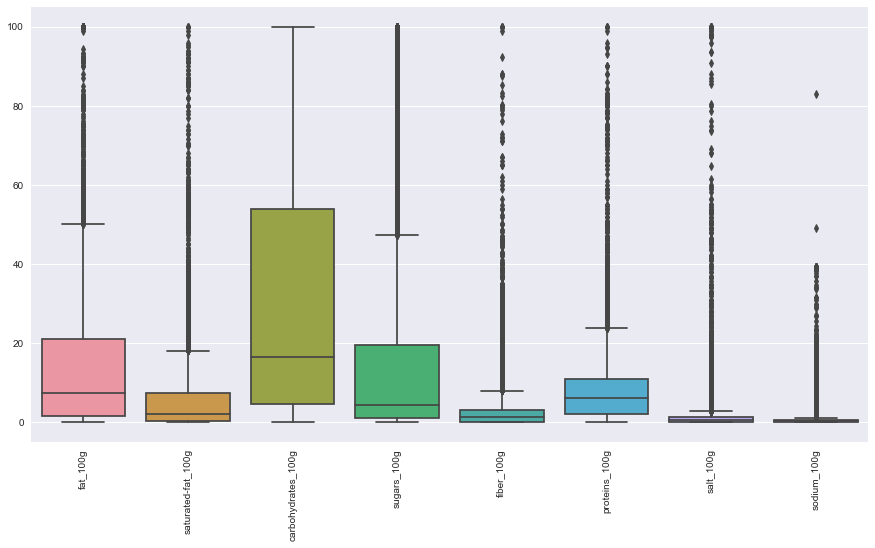

In [54]:
plt.figure(figsize=(15,8))

ax = sns.boxplot(data=datas.loc[:, nutri_unite_g])
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'energy_100g')]

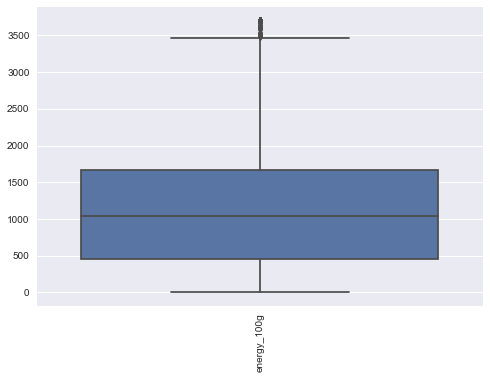

In [55]:
ax = sns.boxplot(data=datas.loc[:, nutri_energy])
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

Pour l'énergie, les outliers sont proches de la borne haute, et sont des valeurs sous le seuil défini précédemment.

Pour les nutriments, il apparait des outliers dans les boxplots.  

Afin de définir si ces outliers sont vraiment des valeurs aberrantes ou pas, le tableau ci-après affiche les valeurs des bornes selon la méthode des 1.5 * interquartiles.


In [56]:
# fonction retournant les bornes limites des valeurs aberrantes selon la règle de 1.5 * écart interquantile
def bornes_interquantiles(df, col):
    q1 = round(np.nanpercentile(df[col], 25))
    q3 = round(np.nanpercentile(df[col], 75))
    ecart_interquartile = q3 - q1
    borne_inferieure = q1 - 1.5 * ecart_interquartile
    borne_superieure = q3 + 1.5 * ecart_interquartile
    return [borne_inferieure,borne_superieure]

In [57]:
# retourne les bornes de la fonction bornes_interquantiles pour chaque colonne du paramètre cols
def valeurs_atypiques(df,cols):
    atypiques={}
    for col in cols:
        [borne_inferieure,borne_superieure] = bornes_interquantiles(datas, col)
        atypiques[col]=[borne_inferieure,borne_superieure]
    return atypiques

In [58]:
atypiques=valeurs_atypiques(datas,nutri_unite_g)
pd.DataFrame(list(atypiques.items()),columns=['Colonne', 'Bornes'])

,Colonne,Bornes
0,fat_100g,"[-26.5, 49.5]"
1,saturated-fat_100g,"[-12.0, 20.0]"
2,carbohydrates_100g,"[-68.5, 127.5]"
3,sugars_100g,"[-27.5, 48.5]"
4,fiber_100g,"[-4.5, 7.5]"
5,proteins_100g,"[-11.5, 24.5]"
6,salt_100g,"[-1.5, 2.5]"
7,sodium_100g,"[0.0, 0.0]"


Les valeurs négatives sont dues au fait que la majorité des valeurs sont assez proches de 0, donc les valeurs atypiques plus élevées font que la différence médiane et écart interquantile est négative.  


Les seuils des valeurs atypiques du sel et des fibres sont plus bas que les autres.  
Pour les fibres, la canelle, l'aliment le plus en fibres, a une teneur en fibres de 43,50 g pour 100g.  
Pour le sel, le sel non iodé non fluoré, l'aliment le plus en sel, a une teneur en sel de 39,10 g pour 100g.  
Pour le sodium, 1 g de sodium = 2,5 g de sel.

Le seuil de 40 grammes pour le sel et les fibres va être considéré comme valeur aberrante.  
Le seuil de 16 grammes (40/2.5) pour le sodium va être considéré comme valeur aberrante.
Le seuil de 100 grammes est gardé pour les autres nutriments.

Les valeurs au dessous de ces seuils et au delà des nornes du tableau ci-dessus sont considérées comme atypiques mais pas aberrantes, elles sont gardées dans le jeu de données.

Exemple pour le sel:  
Entre 2.5 et 40 : valeur atypique  
Au dessus de 40 : valeur aberrante  

In [59]:
filter_values(datas,'salt_100g',0,40)
filter_values(datas,'fiber_100g',0,40)
filter_values(datas,'sodium_100g',0,16)


### 4.5 - Imputation des valeurs manquantes <a class="anchor" id="section_4_5"></a>

Etat des lieux des valeurs manquantes:

In [60]:
table_valeurs_manquantes(datas)

,% de valeurs manquantes
carbohydrates_100g,30.804533
fat_100g,30.707576
fiber_100g,25.907093
energy_100g,0.521417
sodium_100g,0.361975
salt_100g,0.361975
sugars_100g,0.148668
saturated-fat_100g,0.144359
proteins_100g,0.142205
nutrition-score-fr_100g,0.000000


Après ce nettoyage des données, il reste des valeurs manquantes.  
Ces valeurs vont être imputées avec l'algorithme Knn Imputer

In [61]:
from sklearn.impute import KNNImputer 

datas_imputed = datas.copy()
k=5
imputer = KNNImputer(n_neighbors=k) 
datas_imputed[nutrition_columns] = imputer.fit_transform(datas_imputed[nutrition_columns])


In [62]:
table_valeurs_manquantes(datas_imputed)

,% de valeurs manquantes
nutrition-score-fr_100g,0.0
sodium_100g,0.0
salt_100g,0.0
proteins_100g,0.0
fiber_100g,0.0
sugars_100g,0.0
carbohydrates_100g,0.0
saturated-fat_100g,0.0
fat_100g,0.0
energy_100g,0.0


Toutes les valeurs manquantes ont bien été imputées.  
Comparaison des distributions avant et après imputation:

In [63]:
nutri_list = nutri_unite_g + nutri_unite_mg + nutri_unite_ug + nutri_energy

In [64]:

def graph_quantitatives_compare():
    graph_rows = 9
    graph_columns = 2
    fig, axs = plt.subplots(graph_rows, graph_columns, figsize=(15, 45))
    current_row = 0
    current_column = 0

    for col in nutri_list:
        ax = sns.histplot(data=datas, x=col, kde=True, ax=axs[current_row, current_column])
        ax = sns.histplot(data=datas_imputed, x=col, kde=True, ax=axs[current_row, current_column+1])
        current_column+=2
        if current_column == graph_columns:
            current_row+=1
            current_column=0
    axs[0,0].set_title('Avant imputation')
    axs[0,1].set_title('Après imputation')
    return ax.plot()

[]

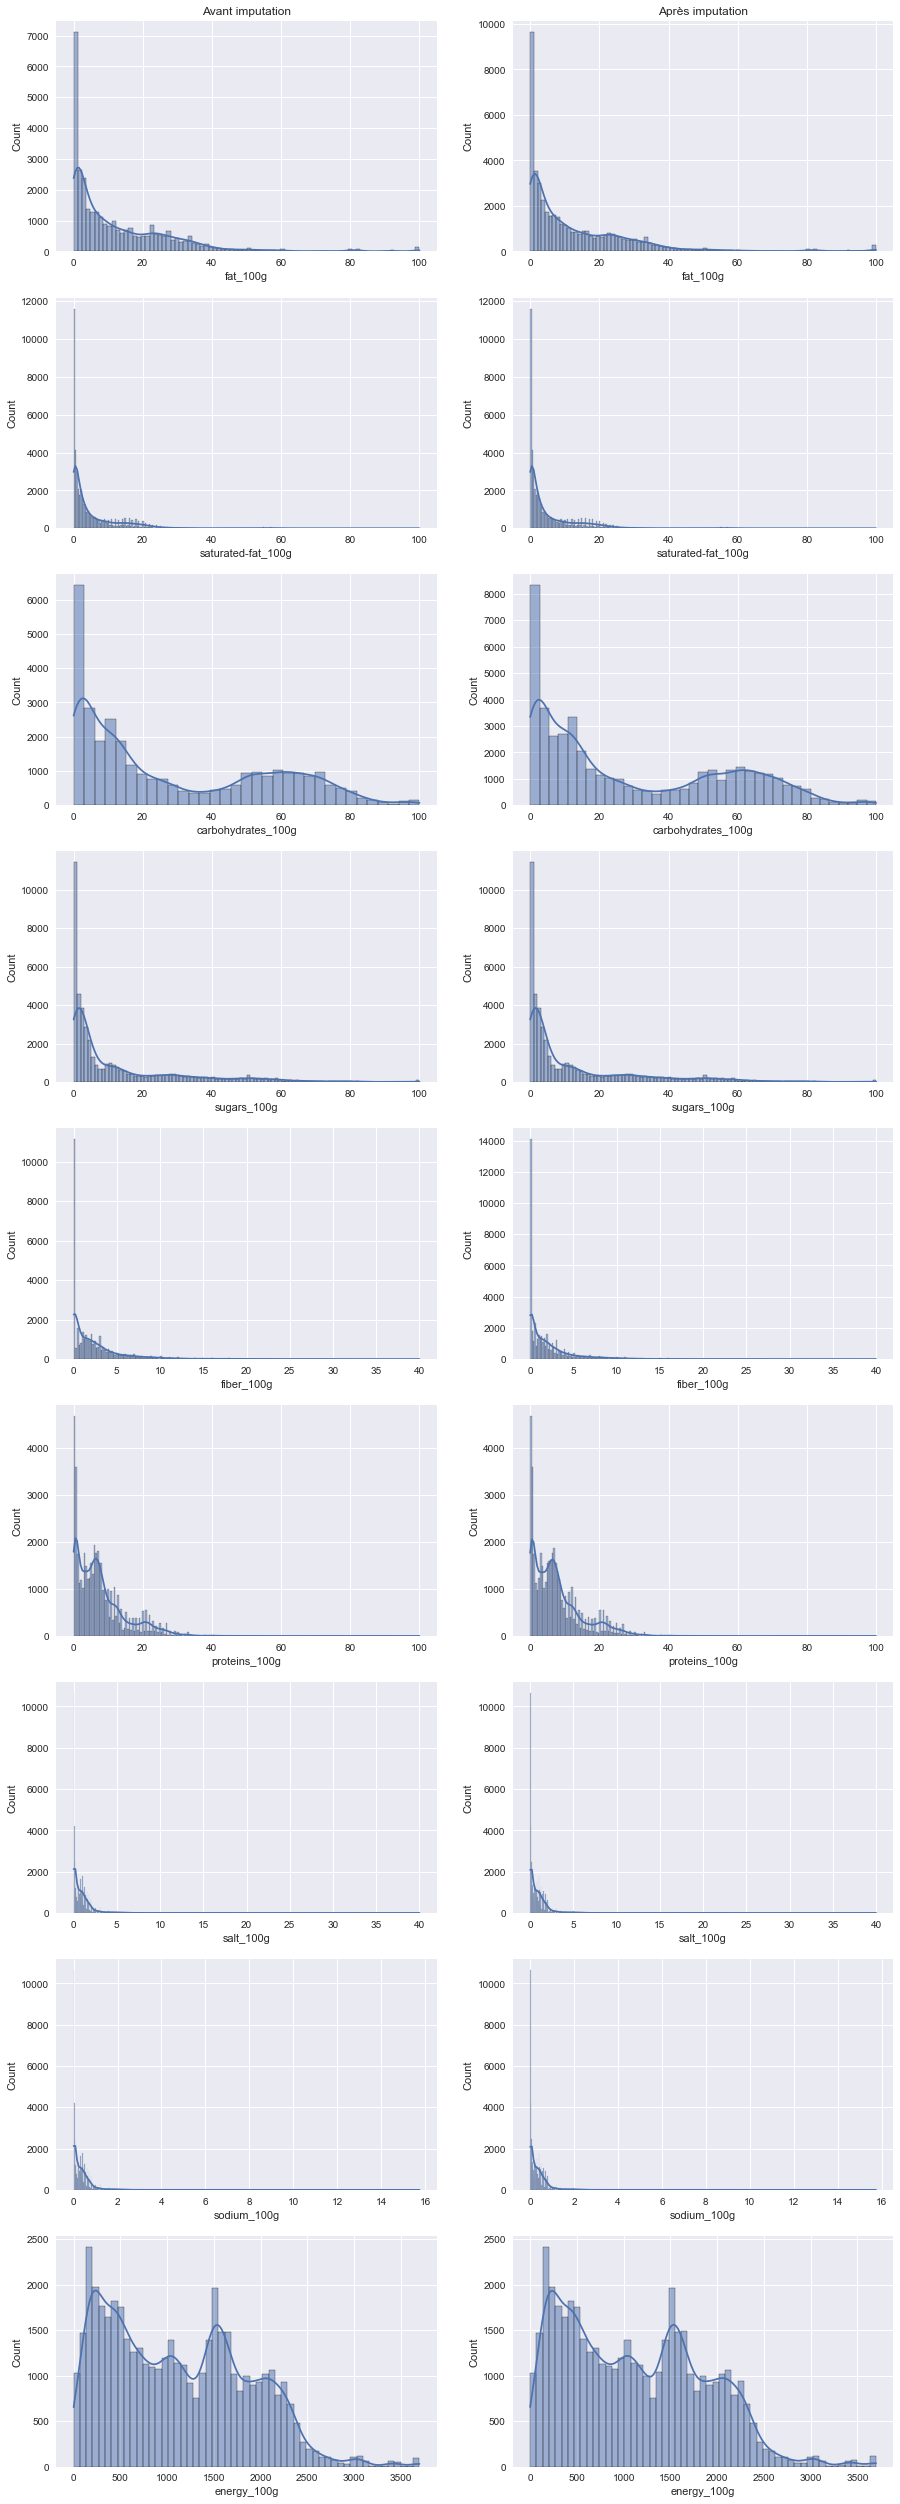

In [65]:
graph_quantitatives_compare()

Les distributions restent similaires.  
L'imputation ne changera pas le résultat de modèles et d'analyses effectués à partir de ces distributions.


### 4.6 - Export des données nettoyées<a class="anchor" id="section_4_6"></a>

In [66]:
print(f"Le jeu de données nettoyé se compose de {datas.shape[0]} lignes et {datas.shape[1]} colonnes ")

Le jeu de données nettoyé se compose de 46412 lignes et 12 colonnes 


Afin de pouvoir utiliser ce jeu de données sans refaire tous les traitements précédents,  
les données sont exportées sous forme persistente dans un fichier csv.  
C'est ce jeu de données qui sera utilisé par le prototype.

In [67]:
datas= datas_imputed.copy()

In [68]:
datas.to_csv(data_path + 'fr.openfoodfacts.org.products_cleaned.csv',index=False)

## 5 - Analyse exploratoire des données <a class="anchor" id="chapter5"></a>

### 5.1 - Visualisation des distributions <a class="anchor" id="section_5_1"></a>

#### Les informations nutritionnelles

In [69]:

def graph_quantitatives(df):
    graph_rows = 3
    graph_columns = 3
    fig, axs = plt.subplots(graph_rows, graph_columns, figsize=(15, 15))
    current_row = 0
    current_column = 0

    for col in nutri_list:
        ax = sns.histplot(data=datas, x=col, kde=True, ax=axs[current_row, current_column])
        current_column+=1
        if current_column == graph_columns:
            current_row+=1
            current_column=0

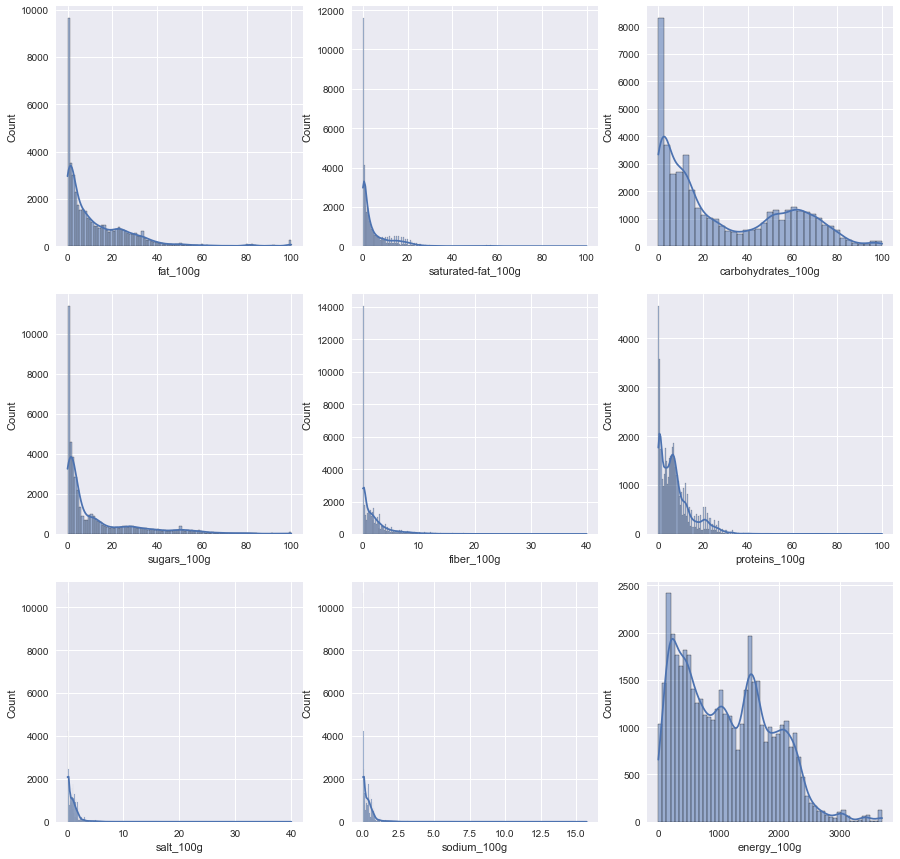

In [70]:

graph_quantitatives(datas)


Les distributions ne suivent pas la loi normale.  
Les distributions de l'énergie et des carbohydrates sont bimodales.  
Les distributions des autres nutriments sont asymétriques et étalées à droite.
Le mode est à 0.

#### Le nutriscore

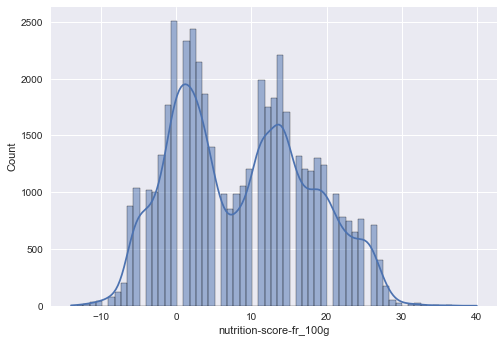

In [71]:
ax = sns.histplot(data=datas, x='nutrition-score-fr_100g', kde=True)


Les valeurs vont de -15 à 40, ce qui est conforme à la théorie:  
Nutri-Score A : -15 à -1  
Nutri-Score B : 0 à 2  
Nutri-Score C : 3 à 10  
Nutri-Score D : 11 à 18  
Nutri-Score E : 19 à 40  

La distribution est bimodale.

#### Le nutrigrade

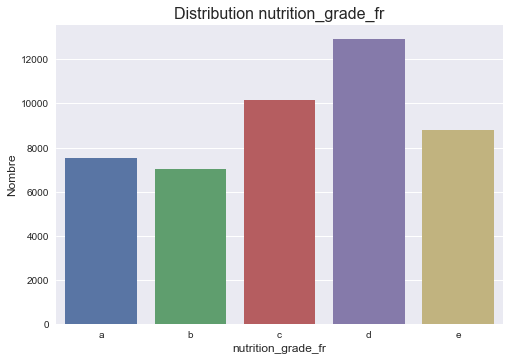

In [72]:
ax = sns.countplot(x="nutrition_grade_fr", data=datas, order=['a','b','c','d','e'])
plt.xlabel('nutrition_grade_fr', fontsize=12)
plt.ylabel('Nombre', fontsize=12)
plt.title('Distribution nutrition_grade_fr', fontsize=16)
plt.show()

La répartition des nutrigrades est assez uniforme.  
Il n'y a pas un grade sous ou sur représenté.  
Le grade le plus représenté est 'd' et le moins représenté est 'b'

### 5.2 - Analyse multivariée <a class="anchor" id="section_5_2"></a>

Le graphique dynamique suivant permet de visualiser à partir d'une colonne choisie (abscisse):  
Sa distribution selon le nutrigrade
Le nuage de points en fonction d'une deuxième colonne choisie (ordonnée) catégorisé selon le nutrigrade.

Ces graphiques permettent de visualiser le comportement d'une variable quantitative selon une autre variable et le nutrigrade.

Le focus de l'analyse sera fait sur le comportement des nutriments en fonction du nutriscore (quantitatif).  

In [73]:
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, FloatSlider, IntSlider
from ipywidgets import Button, HBox, VBox

grades = np.unique(np.array(datas['nutrition_grade_fr']))

x_col=list(nutrition_columns)
y_col=list(nutrition_columns)
bins_values = IntSlider(value=10,description='bins',min=1,max=20,step=1)
kde_value = widgets.Checkbox(description='kde',)

def multivariate_graphs(abscisse, ordonnee, bins, kde):
    graph_rows = 1
    graph_columns = 5
    fig, axs = plt.subplots(graph_rows, graph_columns, figsize=(15, 5))
    i=0
    for grade in grades:
        ax = sns.histplot(datas[datas['nutrition_grade_fr']==grade], x=abscisse,kde=kde, bins=bins,hue="nutrition_grade_fr",ax=axs[i])
        i+=1
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=datas, x=abscisse, y=ordonnee,hue="nutrition_grade_fr",hue_order=['a','b','c','d','e'],alpha=1)


interact(multivariate_graphs, abscisse=x_col,ordonnee=y_col,bins=bins_values,kde=kde_value)





interactive(children=(Dropdown(description='abscisse', options=('energy_100g', 'fat_100g', 'saturated-fat_100g…

<function __main__.multivariate_graphs(abscisse, ordonnee, bins, kde)>

L'analyse en fonction du nutriscore permet de voir:  

- Pour l'énergie, le gras, le gras saturé et les sucres:
  - lorsque la quantité augmente:
    - le nombre d'individus avec le grade 'a' diminue
    - il n'y a plus de grade 'a' dans les hautes valeurs
  - toutes les valeurs de nutriscores (et grade) sont représentées pour les faibles valeurs
  - les nutriscores élevés, (ou grades d,e) restent toutefois stables quelle que soit la quantité de ces nutriments (et énergie)
  
  --> ces nutriments influent sur le nutriscore, cependant leur absence n'influe pas sur le nutriscore
  
  
- La même observation peut être faite pour le sel et le sodium, mais à la différence qu'il existe peu d'individus avec de grandes quantités de ces nutriments.  
La différence avec peu ou pas de sel est moins marquée qu'avec les informations précédentes.


- Pour les fibres, plus il y en a, moins il y a de grade e, ou de score élevé.  
Toutefois, dans les faibles quantités de fibres, on observe la présence de tous les grades, dans des proportions similaires.  

  --> la présence de fibres influe positivement sur le score, toutefois son absence n'évite pas de mauvais scores.    
  
  
- Sur les graphes avec les carbohydates et les protéines, on n'observe pas de corrélation.

- On observe une corrélation linéaire entre le sel et le sodium.  
- On observe aussi une coorélation entre le nutriscore (quantitatif) et le nutrigrade (qualitatif).



#### Matrice de corrélation:

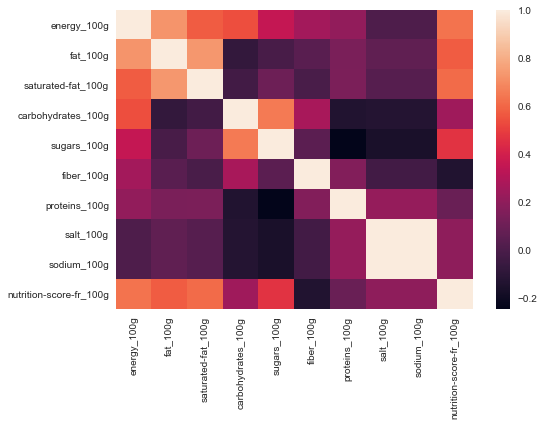

In [74]:
ax = sns.heatmap(datas.corr())

Les nutriments les plus corrélés avec le nutriscore (quantitatif) sont l'énergie, les gras et gras saturés.  
La coefficient de corrélation entre le sel et le sdium est de 1.

### 5.3 - Hypothèses <a class="anchor" id="section_5_3"></a>

Dans les graphiques à nuages de points, le nutrigrade (qualitatif) semble corrélé avec plusieurs nutriments.  
Le nutrigrade apparait aussi corrélé avec le nutriscore (quantitatif).  
La matrice de corrélation montre des coefficients plus élevés pour la corrélation entre le nutriscore et l'énergie, les gras et gras saturés.  

Hypothèses:  

- La corrélation entre le nutriscore et le nutrigrade est élevée.  
L'énergie, le gras et le gras saturés sont aussi corrélés avec le nutrigrade.

  --> Afin de vérifier que certains nutriments influencent plus ou moins le nutrigrade (qualitatif),
une analyse de la variance (ANOVA) va être réalisée.  


- L'ensemble des nutriments semblent influer sur le nutriscore, de manière différente.  
  Ces nutriments semblent avoir des liens entre eux, comme les gras et gras saturés ou les glucides et les sucres.  
  Le regroupement ou l'association de ces nutriments peuvent aussi influer sur le nutriscore et le nutrigrade.  

  --> Une analyse en composante principales va être effectuée afin de créer des variables synthétiques et d'analyser le jeu de données avec ces nouvelles variables.



### 5.4 - Anova <a class="anchor" id="section_5_4"></a>

In [75]:

def nutrition_groupes(col):
    X = "nutrition_grade_fr" # qualitative
    Y = col # quantitative
    modalites = datas[X].unique()
    groupes=dict()
    for m in modalites:
        groupes[m]=datas[datas[X]==m][Y]
    return groupes

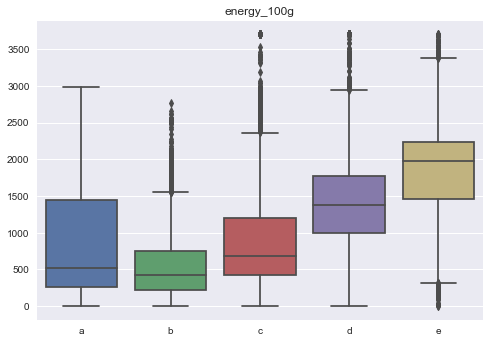

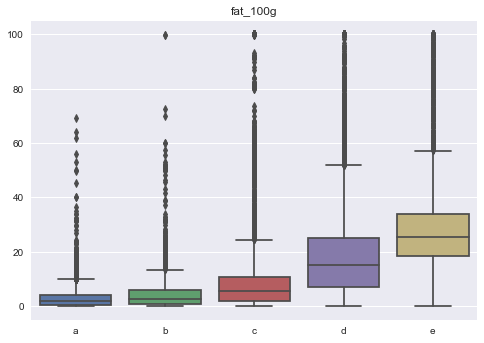

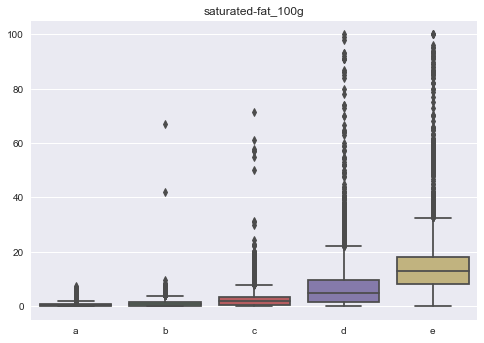

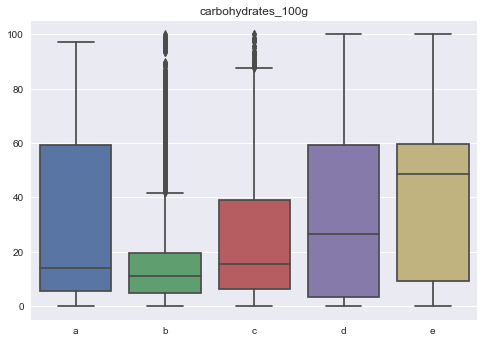

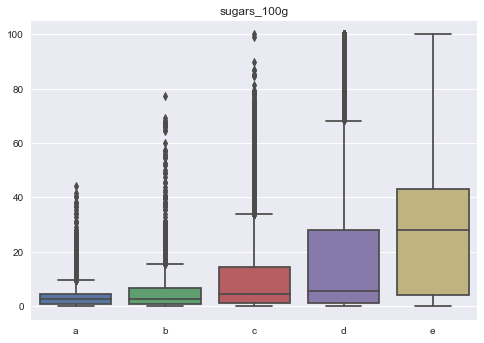

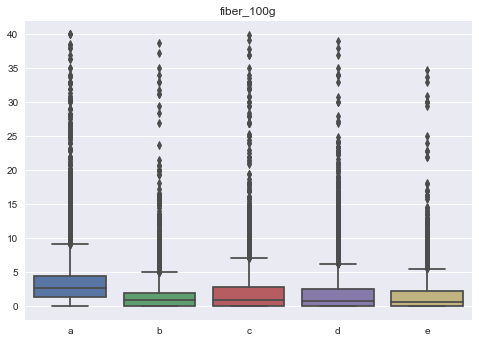

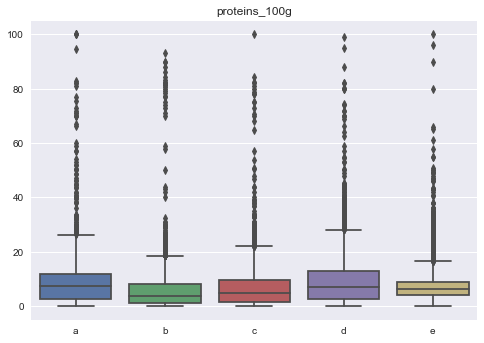

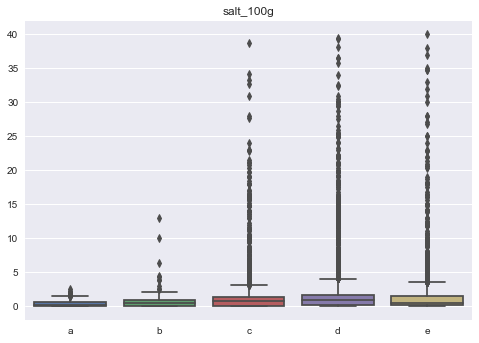

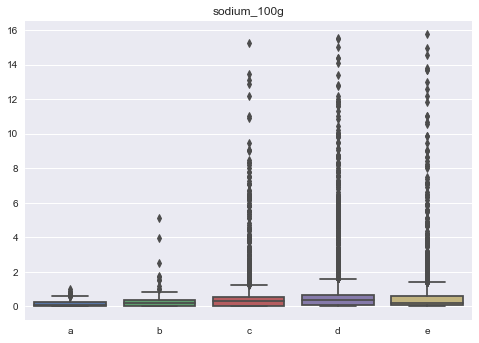

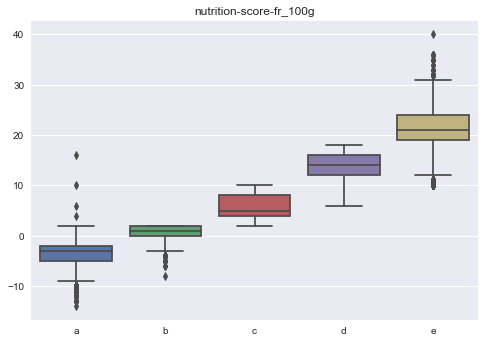

In [76]:
#for col in nutri_list:
for col in nutrition_columns:
    plt.figure()
    df_groupes=pd.DataFrame(nutrition_groupes(col))
    sns.boxplot(data=df_groupes.sort_index(axis = 1, ascending = True)).set_title(col)


Le nutrigrade ne semble pas être beaucoup influencé par les protéines, le sel, le sodium, les carbohydrates, les fibres.  
En revanche, la dispersion de l'énergie et des lipides (fat, saturated fat) semble corrélée au nutrigrade.

Le tableau suivant affiche les valeurs 'eta carré' et 'p value':

In [77]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [78]:
# calcul anova
def anova_table(col1,col2):
    lm = ols(col1 + '~' + col2,data=datas).fit()
    table = sm.stats.anova_lm(lm)
    return table

In [79]:
# calcul du rapport de corrélation
def rapport_corelation(table):
    sce = table["sum_sq"]["nutrition_grade_fr"]
    scr = table["sum_sq"]["Residual"]
    sct = sce + scr
    eta_squared = sce/sct
    return eta_squared

In [80]:
# création d'une dataframe pour contenir les informations recueillies 
columns_df = ['colonne','rapport corelation','pvalue']
df_anova = pd.DataFrame(columns=columns_df)

In [81]:
# la fonction ols ne fonctionne pas avec le symbole '-' dans le nom des colonnes
datas.rename(columns={'saturated-fat_100g': 'saturated_fat_100g'}, inplace=True)
datas.rename(columns={'nutrition-score-fr_100g': 'nutrition_score_fr_100g'}, inplace=True)
nutrition_columns = ['saturated_fat_100g' if value=='saturated-fat_100g' else value for value in nutrition_columns]
nutrition_columns = ['nutrition_score_fr_100g' if value=='nutrition-score-fr_100g' else value for value in nutrition_columns]

# calcul des valeurs pour chaque colonne
for col in nutrition_columns:
    table = anova_table(col,'nutrition_grade_fr')
    corelation = rapport_corelation(table)
    pvalue=table["PR(>F)"]["nutrition_grade_fr"]
    df_new_line = pd.DataFrame([[col,corelation,pvalue]], columns=columns_df)    
    df_anova = pd.concat([df_anova,df_new_line], ignore_index=True)

In [82]:
df_anova.sort_values(by=['rapport corelation'], ascending=False)

,colonne,rapport corelation,pvalue
9,nutrition_score_fr_100g,0.913732,0.000000e+00
2,saturated_fat_100g,0.344294,0.000000e+00
0,energy_100g,0.336404,0.000000e+00
1,fat_100g,0.279588,0.000000e+00
4,sugars_100g,0.185499,0.000000e+00
3,carbohydrates_100g,0.058802,0.000000e+00
5,fiber_100g,0.051247,0.000000e+00
7,salt_100g,0.040848,0.000000e+00
8,sodium_100g,0.040848,0.000000e+00
6,proteins_100g,0.019975,2.181312e-201


On peut observer que les coefficients de corrélation pour les lipides et l'énergie sont bien plus élevés que pour les autres nutriments.  
Ce qui confirme les observations précédentes.  
Le coefficient de corrélation entre le nutriscore et le nutrigrade est presque de 1.  

Hypothèse nulle : la distribution du nutriment est similaire quel que soit le nutrigrade.  
La p value est de 0, l'hypothèse nulle est rejetée.  
Ces nutriments impactent le nutrigrade.


In [83]:
datas.rename(columns={'saturated_fat_100g': 'saturated-fat_100g'}, inplace=True)
datas.rename(columns={'nutrition_score_fr_100g': 'nutrition-score-fr_100g'}, inplace=True)
nutrition_columns = ['saturated-fat_100g' if value=='saturated_fat_100g' else value for value in nutrition_columns]
nutrition_columns = ['nutrition-score-fr_100g' if value=='nutrition_score_fr_100g' else value for value in nutrition_columns]


### 5.5 - ACP <a class="anchor" id="section_5_5"></a>

#### standardisation

In [84]:
from sklearn import preprocessing

std_scale = preprocessing.StandardScaler().fit(datas[nutrition_columns])
datas_scaled = std_scale.transform(datas[nutrition_columns])
datas_scaled = pd.DataFrame(datas_scaled,datas[nutrition_columns].index,datas[nutrition_columns].columns)

datas = pd.concat([datas_scaled,datas[['product_name','nutrition_grade_fr']]],axis=1)


#### fonctions pour l'acp

In [85]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import pandas as pd

def display_circles(pcs, n_comp, pca, axis_ranks, labels=None, label_rotation=0, lims=None):
    for d1, d2 in axis_ranks: # On affiche les 3 premiers plans factoriels, donc les 6 premières composantes
        if d2 < n_comp:

            # initialisation de la figure
            fig, ax = plt.subplots(figsize=(7,6))

            # détermination des limites du graphique
            if lims is not None :
                xmin, xmax, ymin, ymax = lims
            elif pcs.shape[1] < 30 :
                xmin, xmax, ymin, ymax = -1, 1, -1, 1
            else :
                xmin, xmax, ymin, ymax = min(pcs[d1,:]), max(pcs[d1,:]), min(pcs[d2,:]), max(pcs[d2,:])

            # affichage des flèches
            # s'il y a plus de 30 flèches, on n'affiche pas le triangle à leur extrémité
            if pcs.shape[1] < 30 :
                plt.quiver(np.zeros(pcs.shape[1]), np.zeros(pcs.shape[1]),
                   pcs[d1,:], pcs[d2,:], 
                   angles='xy', scale_units='xy', scale=1, color="grey")
                # (voir la doc : https://matplotlib.org/api/_as_gen/matplotlib.pyplot.quiver.html)
            else:
                lines = [[[0,0],[x,y]] for x,y in pcs[[d1,d2]].T]
                ax.add_collection(LineCollection(lines, axes=ax, alpha=.1, color='black'))
            
            # affichage des noms des variables  
            if labels is not None:  
                for i,(x, y) in enumerate(pcs[[d1,d2]].T):
                    if x >= xmin and x <= xmax and y >= ymin and y <= ymax :
                        plt.text(x, y, labels[i], fontsize='14', ha='center', va='center', rotation=label_rotation, color="blue", alpha=0.5)
            
            # affichage du cercle
            circle = plt.Circle((0,0), 1, facecolor='none', edgecolor='b')
            plt.gca().add_artist(circle)

            # définition des limites du graphique
            plt.xlim(xmin, xmax)
            plt.ylim(ymin, ymax)
        
            # affichage des lignes horizontales et verticales
            plt.plot([-1, 1], [0, 0], color='grey', ls='--')
            plt.plot([0, 0], [-1, 1], color='grey', ls='--')

            # nom des axes, avec le pourcentage d'inertie expliqué
            plt.xlabel('F{} ({}%)'.format(d1+1, round(100*pca.explained_variance_ratio_[d1],1)))
            plt.ylabel('F{} ({}%)'.format(d2+1, round(100*pca.explained_variance_ratio_[d2],1)))

            plt.title("Cercle des corrélations (F{} et F{})".format(d1+1, d2+1))
            plt.show(block=False)
        
def display_factorial_planes(X_projected, n_comp, pca, axis_ranks, labels=None, alpha=1, illustrative_var=None,filter_value='all'):
    for d1,d2 in axis_ranks:
        if d2 < n_comp:
 
            # initialisation de la figure       
            fig = plt.figure(figsize=(7,6))
        
            # affichage des points
            if illustrative_var is None:
                plt.scatter(X_projected[:, d1], X_projected[:, d2], alpha=alpha)
            else:
                illustrative_var = np.array(illustrative_var)
                for value in np.unique(illustrative_var):
                    if (value in np.array(filter_value)) | (filter_value == 'all'):
                        selected = np.where(illustrative_var == value)
                        ax = plt.scatter(X_projected[selected, d1], X_projected[selected, d2], alpha=alpha, label=value)
                plt.legend()

            # affichage des labels des points
            if labels is not None:
                for i,(x,y) in enumerate(X_projected[:,[d1,d2]]):
                    plt.text(x, y, labels[i],
                              fontsize='14', ha='center',va='center') 
                
            # détermination des limites du graphique
            boundary = np.max(np.abs(X_projected[:, [d1,d2]])) * 1.1
            plt.xlim([-boundary,boundary])
            plt.ylim([-boundary,boundary])
        
            # affichage des lignes horizontales et verticales
            plt.plot([-100, 100], [0, 0], color='grey', ls='--')
            plt.plot([0, 0], [-100, 100], color='grey', ls='--')

            # nom des axes, avec le pourcentage d'inertie expliqué
            plt.xlabel('F{} ({}%)'.format(d1+1, round(100*pca.explained_variance_ratio_[d1],1)))
            plt.ylabel('F{} ({}%)'.format(d2+1, round(100*pca.explained_variance_ratio_[d2],1)))

            plt.title("Projection des individus (sur F{} et F{})".format(d1+1, d2+1))
            plt.show(block=False)

def display_scree_plot(pca):
    scree = pca.explained_variance_ratio_*100
    plt.bar(np.arange(len(scree))+1, scree)
    plt.plot(np.arange(len(scree))+1, scree.cumsum(),c="red",marker='o')
    plt.xlabel("rang de l'axe d'inertie")
    plt.ylabel("pourcentage d'inertie")
    plt.title("Eboulis des valeurs propres")
    plt.show(block=False)

#### acp

In [86]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=6)
pca.fit(datas[nutrition_columns])

PCA(n_components=6)

#### Eboulis des valeurs propres


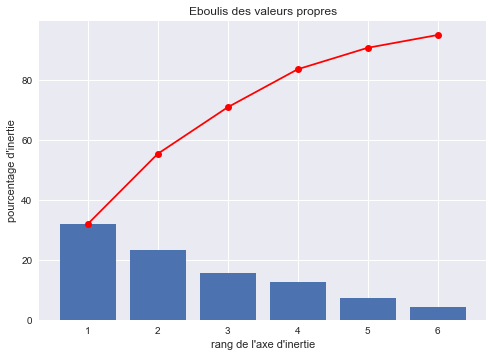

In [87]:
display_scree_plot(pca)

Plus de 80% de l'inertie est représentée avec les 4 premières composantes.  
L'analyse se basera sur ces 4 composantes.

#### Cercle des corrélations

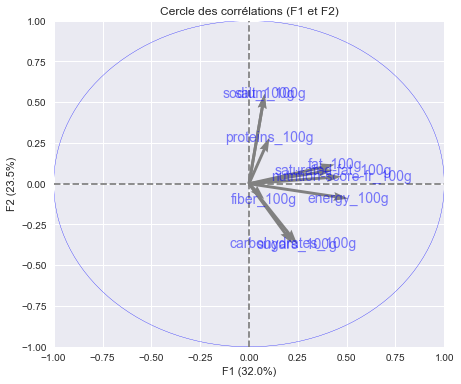

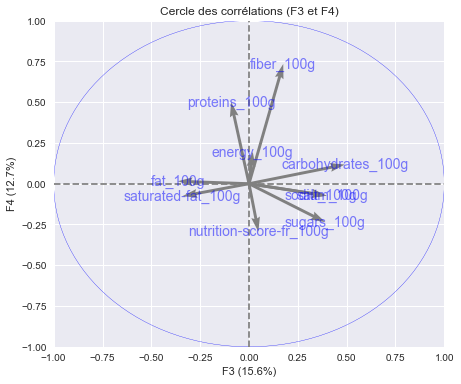

In [88]:
#%matplotlib notebook

# Cercle des corrélations
pcs = pca.components_
display_circles(pcs, 6, pca, [(0,1),(2,3)], labels = np.array(nutrition_columns))


- Sur le premier cercle, axes F1 et F2:

On observe un goupe composé de l'énergie, le nutriscore, le gras et le gras saturé.  
Les flèches sont proches de l'axe F1 (angle) et leurs projections sur cet axe sont d'environ 0.5.  

Le sel, le sodium sont proches de l'axe F2 vers le haut,  
tandis que le sucre et les glucides, plus proches de l'axe F2 que de F1, sont dirigés vers le bas.  

Les lipides (gras, gras saturé) sont les nutriments les plus calorifiques, et qui apportent le plus d'énergie.  
***L'axe F1 peut représenter cet aspect calorifique, énergétique.***  
***L'axe F2 peut représenter l'aspect sucré/salé.***


- Sur le deuxième cercle, axes F3 et F4:  

Sucres, glucides,sel, sodium sont corélés à l'axe F3 dans le sens positif et  
les lipides sont aussi corélés à F3, dans le sens négatif.  

Les glucides sont rapidement digérés pour la plupart.  
Inversement, les lipides permettent de rallonger le temps de digestion.  
***L'axe F3 peut ainsi représenter le temps de digestion.***

Les fibres sont bien corrélées à l'axe F4, les protéines aussi dans une moindre mesure.  
Ce sont les nutriments qui atténuent le plus la sensation de faim, qui agissent le plus sur la satiété.  
***L'axe F4 peut ainsi représenter la satiété.***


- Autre observation sur les deux cercles:  

On voit aussi que:  
Le sel et le sodium sont confondus sur les deux cercles. Ces nutriments sont très corrélés.  
Le sucre et les glucides (carbohydrates) sont corrélés sur le premier cercle et un peu moins sur le deuxième.  






#### projection des individus

In [89]:
X_projected = pca.transform(datas[nutrition_columns])


In [90]:
grades_acp = np.array('all')
grades_acp = np.append(grades_acp,np.unique(np.array(datas['nutrition_grade_fr'])))

nutrigrade_list = widgets.SelectMultiple(
    options=['a', 'b', 'c', 'd', 'e'],
    value=['a'],
    #rows=10,
    description='Nutrigrade',
    disabled=False
)

alpha_values = FloatSlider(value=1,description='Transparence',min=0,max=1,step=0.1)


@interact
def show_articles_more_than(grade=nutrigrade_list,alpha_value=alpha_values):
    display_factorial_planes(X_projected, 6, pca, [(0,1),(2,3)], illustrative_var = datas['nutrition_grade_fr'],filter_value=grade,alpha=alpha_value)
    



interactive(children=(SelectMultiple(description='Nutrigrade', index=(0,), options=('a', 'b', 'c', 'd', 'e'), …

Les axes:
- F1 energetique
- F2 sucré/salé
- F3 temps de digestion
- F4 satiété

Les individus avec un nutriscore 'a' sont:
  - centrés sur le graphique avec les axes F1 et F2.
  - dispersés le long de l'axe F4.

En faisant évoluer le nutrigrade de 'a' vers 'e', on observe:
- de plus en plus d'individus sur l'axe F2 positivement, c'est à dire avec un caractère salé.
- de plus en plus d'individus sur l'axe F3 positivement, c'est à dire avec un temps de digestion long.
- de moins en moins d'individus sur l'axe F4 positivement, c'est à dire avec une satiété qui diminue.


En comparant les nutrigrades par deux, sur le graphique avec les axes F1 et F2:
- Le nutrigrade supérieur recouvre le nutrigrade précédent et s'étend positivement vers F1 et F2



**Sur le graphique avec les axes F1 et F2 :**

On constate que lorsque les valeurs sont importantes sur les axes, on n'a pas de bon nutrigrade (valeur 'a').  
Si elles sont faibles, on a tous les nutrigrades.  

On observe donc qu'avec des valeurs importantes sur les axes F1 et F2, le nutriscore est impacté négativement.
En revanche des valeurs faibles ne garantissent pas un bon nutriscore.  
Lorsque les valeurs sont faibles, la répartition est similaire pour chaque grade, il n'y a pas de corrélation.

**Sur le graphique avec les axes F3 et F4 :**

Le nutriscore est impacté positivement lorsque les aliments diminuent la sensation de faim.    
Il est impacté négativement lorsque les aliments se digèrent rapidement.  



## 6 - Conclusion <a class="anchor" id="chapter6"></a>

La base de données Open Food Facts est importante, et de nombreuses informations sont présentes.  
Même en se focalisant sur quelques indicateurs, un nettoyage des données a dû être effectué pour pouvoir effectuer une analyse.

Avec cette analyse, il apparait que les nutriments impactent le nutriscore.  
Certains semblent impacter le nutriscore plus que d'autres, mais il n'existe pas de corrélation directe entre un nutriment et le nutriscore.  

De manière générale, il semble qu'en mangeant de manière variée et modérée chaque nutriment, le nutriscore sera moins impacté négativement, et donc l'alimentation sera plus saine.  

**Le nutriscore est ainsi un bon indicateur.**


**Pour compléter cette étude:**
    
Le nettoyage peut être plus poussé comme par exemple la présence de produits non alimentaires dans la base de données.  
De même, un nom de produit comprend parfois une liste de produits.  
Il apparait sur le nuage de la projection des individus de l'ACP quelques outliers qui peuvent être des valeurs aberrantes.   

L'étude s'est focalisée sur les nutriments.  
Il peut être intéressant d'étudier d'autres facteurs impactant le nutriscore, comme :  
la catégorie du produit, ou encore les produits vendus dans tel ou tel pays.  

D'autres études de santé peuvent être menées, notamment en prenant en compte les allergènes  
afin de voir la possibilité de régimes alimentaires sains pour les personnes allergiques.  
